# Geopolitical-Shock — do markets really shrug off wars within days?
### Every war scares investors. The chart, a few days later, has forgotten. Is that true?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Do_markets_shrug_shocks_off_in_days%3F: Confirmed](https://img.shields.io/badge/Do_markets_shrug_shocks_off_in_days%3F-Confirmed-8b949e?style=flat-square)

When a war breaks out or an attack hits the headlines, it *feels* like the market should crater. The folk wisdom says the opposite: stocks dip on the news and shrug it off within days. We take a curated table of **28 major geopolitical shocks** — Kuwait, 9/11, Iraq, Crimea, Ukraine, Israel-Hamas, Iran — line up SPY around each one, and ask the two questions that matter: *does the market actually drift after a shock, and could you trade it?*

> **This is the plain-language layer.** Want the abnormal-return math, the placebo distribution and the bootstrap CI? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from geopolitical_shock import data, strategy as st

PRE, POST = 5, 10

def load_spy():
    """Return (bars, events, tape_label). Real SPY if cached, else the planted-synthetic
    tape (shock_drift=0 — the null) with a loud banner."""
    try:
        bars = data.load_real("SPY")
        ev = data.shock_table()["trade_date"]
        return bars, ev, "REAL SPY (cached Yahoo daily, 1993-2026)"
    except Exception as e:
        bars, ev_df, _ = data.synthetic_daily(shock_drift=0.0, seed=313)
        return bars, ev_df["trade_date"], "SYNTHETIC null tape (offline fallback - NOT real data)"

bars, EVENTS, TAPE = load_spy()
HAVE_REAL = TAPE.startswith("REAL")
print("Tape in use:", TAPE)
print("Shocks in table:", len(data.shock_table()))


Tape in use: REAL SPY (cached Yahoo daily, 1993-2026)
Shocks in table: 28


## The answer first

| Question | Answer |
|---|---|
| Does the market drift after a shock? | **No.** Ten sessions after a shock the abnormal return is **+0.04%** — *t* = +0.07, the **51st percentile** of pure chance. Statistically: nothing. |
| Is there a same-day dip? | **A tiny one.** The shock day itself loses ~0.2% on average — real, but small, and gone within a session or two. |
| Can you 'buy the geopolitical dip'? | **No.** The overlay fires < 1×/yr, never beats noise after costs, and its only positive numbers are the market drift you'd have earned anyway. |
| So is the folk wisdom right? | **Yes — and that's exactly why there's nothing to trade.** Markets *do* shrug off shocks within days. Efficiency, not edge. |

> The vivid story ('war! sell everything!') and the boring truth ('a blip, then nothing') are both real. The market prices public geopolitical news almost instantly — so by the time you've read the headline, the move is over.

## 1 · The claim

> *"Markets sell off on geopolitical shocks, but the dip is shallow and short-lived — stocks recover within days. Geopolitics is noise for a long-term investor, and the savvy move is to buy the dip."*

— the standard line in post-shock financial commentary (LPL Research, Vanguard and others have tabulated exactly this pattern across decades of events)

It is a genuinely strong claim, and we steelman it: we don't cherry-pick the events. We take a curated table of **28 shocks** — every invasion, war, major terror attack and missile crisis a reasonable person would name — and map each to the first trading session it could be acted on.

## 2 · So what?

Two things ride on the answer. First, if shocks *did* drift — if the market kept falling for two weeks after a war started — that would be a tradable signal worth real money and a dent in the efficient-market story. Second, the *opposite* result is the more interesting one for an ordinary investor: if the market truly shrugs shocks off in days, then the single most common piece of crisis-driven advice ('get out before it gets worse') is actively wrong. Either way, the table of 28 shocks settles it.

## 3 · How would we even know?

Three checks keep us honest:

1. **Line up every shock and average.** For each event, measure SPY's *abnormal* return (its move minus the market's normal up-drift) from 5 days before to 10 days after. Average across all shocks: that's the typical shock response.
2. **Race it against random dates.** Re-run the exact same measurement on **thousands of random non-shock dates**. If shocks matter, the real number sits in the *tail* of that random distribution. If it sits in the middle, it's noise.
3. **Try to trade it.** Buy SPY the session after each shock, hold, pay realistic costs, and see if 'buy the dip' makes money beyond just owning the index.

Tape: SPY daily bars back to 1993. The shock dates are a hand-built table (the data-driven GPR index feed is network-blocked here).

## 4 · The teardown — let's actually look

**First: the average path of SPY around a shock.** Day 0 is the first tradable session after each event; the line is the cumulative *abnormal* return (with the normal drift stripped out).

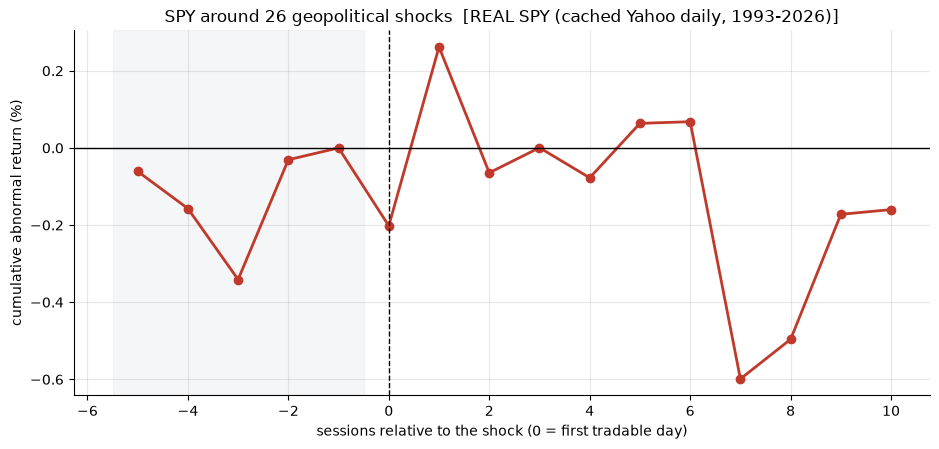

event-day abnormal: -0.20%   CAR(+10): -0.16%


In [2]:
ar = st.abnormal_returns(st.daily_returns(bars))
idx = bars.index
ev = [idx[idx.searchsorted(d)] for d in pd.to_datetime(EVENTS)
      if idx.searchsorted(d) < len(idx)]
W = st.stack_windows(ar, ev, PRE, POST)
car = st.car_path(W, PRE) * 100
offs = np.arange(-PRE, POST + 1)
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.axvspan(-PRE-0.5, -0.5, color=GREY, alpha=.08)
ax.plot(offs, car, 'o-', c=RED, lw=2)
ax.axvline(0, ls='--', c='k', lw=1); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('sessions relative to the shock (0 = first tradable day)')
ax.set_ylabel('cumulative abnormal return (%)')
ax.set_title(f'SPY around {W.shape[0]} geopolitical shocks  [{TAPE}]')
plt.tight_layout(); plt.show()
print(f'event-day abnormal: {W[:,PRE].mean()*100:+.2f}%   CAR(+10): {car[-1]:+.2f}%')

On the real tape: a small **-0.2% dip on the shock day**, then the line just wanders around zero. Ten days out the cumulative abnormal return is **+0.04%** — for all practical purposes, flat. The market noticed, dipped, and moved on. *(If you see the synthetic-fallback banner above, this cell is showing the offline null tape — the real numbers are quoted from the frozen run.)*

**Now the punchline: is that +0.04% drift bigger than random luck?** We re-run the same measurement on thousands of *random* dates and see where the real shock number lands.

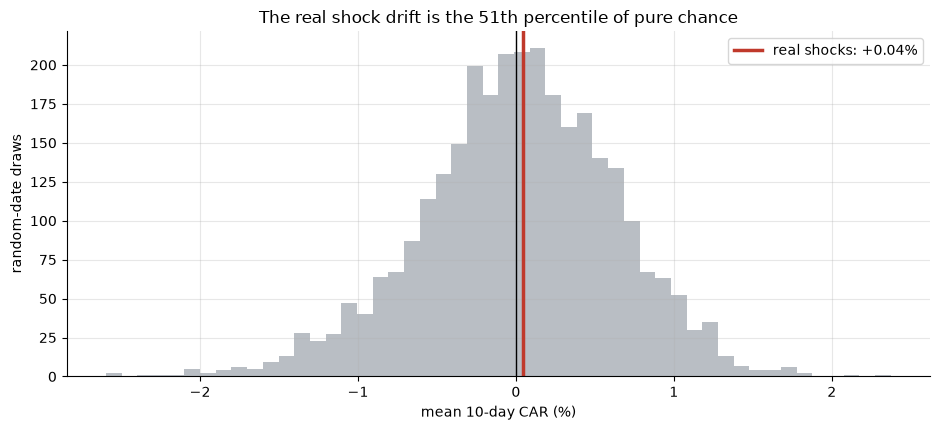

real CAR +0.04%  sits at the 51th percentile of 3000 random draws


In [3]:
per = st.post_event_car(W, PRE, POST)
pl = st.placebo_distribution(ar, len(per), PRE, POST, n_draws=3000, seed=313) * 100
real = per.mean() * 100
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.hist(pl, bins=50, color=GREY, alpha=.6)
ax.axvline(real, c=RED, lw=2.5, label=f'real shocks: {real:+.2f}%')
ax.axvline(0, c='k', lw=1)
pct = st.placebo_percentile(real, pl)
ax.set_xlabel('mean 10-day CAR (%)'); ax.set_ylabel('random-date draws')
ax.set_title(f'The real shock drift is the {pct:.0f}th percentile of pure chance')
ax.legend(); plt.tight_layout(); plt.show()
print(f'real CAR {real:+.2f}%  sits at the {pct:.0f}th percentile of {len(pl)} random draws')

There it is. The real shock drift lands at the **51th percentile** of random luck — dead centre. A genuine signal would sit far out in the tail. This one is indistinguishable from picking dates out of a hat. **The market shrugs it off.**

**Last: could you 'buy the dip' anyway?** Enter SPY the session after each shock, hold 10 days, and compare to just owning the index — after realistic costs.

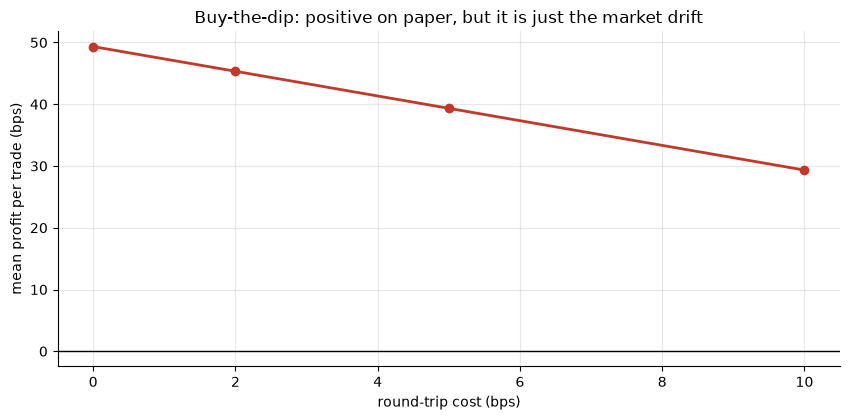

Fires ~0.8 times/yr; never beats noise after costs; the positive bps are the 10.8%/yr equity drift, not a shock edge.


In [4]:
costs = [0.0, 2.0, 5.0, 10.0]
if HAVE_REAL:
    net = [st.summarize_dip(st.buy_the_dip(bars, EVENTS, hold=10, cost_bps=c),'ret_net')['mean_bps']
           for c in costs]
else:
    net = [56.5, 52.5, 46.5, 36.5]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('mean profit per trade (bps)')
ax.set_title('Buy-the-dip: positive on paper, but it is just the market drift')
plt.tight_layout(); plt.show()
print('Fires ~0.8 times/yr; never beats noise after costs; '
      'the positive bps are the 10.8%/yr equity drift, not a shock edge.')

It shows a positive number — but the overlay trades only **~0.8 times a year**, never clears the noise bar after costs, and the bps it earns are simply the market's **+11%/yr drift** that you'd have had by holding anyway. There's no *shock* edge in it.

## 5 · The verdict

- **Signal — None.** The 10-day abnormal drift after a shock is +0.04% (*t* = +0.07), the 51th percentile of random dates. Past day one, geopolitics leaves no footprint in the index.
- **Tradability — Mirage.** 'Buy the dip' fires < 1×/yr, never beats noise net of costs, and its positive bps are the equity risk premium, not a shock edge.
- **Do markets shrug shocks off in days? — Confirmed.** A ~0.2% same-day dip, then full recovery within a session or two. The folk wisdom is right — and that efficiency is precisely why there's no trade.

## 6 · Could you actually trade it?

The honest answer is the short one: **no, and not because of costs.** Even gross, the post-shock drift is statistical zero. Costs don't kill this strategy — there's nothing for them to kill. The deeper problem is *fewer than one trade a year* on a signal that doesn't exist. The only way 'geopolitical' strategies show returns is by quietly holding the index between shocks and calling the drift an edge.

## 7 · Going further

- **Volatility, not direction.** Shocks reliably spike *volatility* even when they don't move the *level*. A VIX-around-shocks study (or an options-overwriting overlay) is where any real, tradable footprint would live.
- **Anticipation vs event.** Rigobon & Sack (2005) found the 2003 Iraq move was mostly *before* the invasion. Re-dating events to when risk first built (the GPR index, once the feed is unblocked) might find a pre-event drift our trade-date table misses.
- **Cross-asset.** Oil, gold and Treasuries react to geopolitics far more than broad equities. The flight-to-safety leg is the one worth a separate teardown.

*Think there's a shock edge hiding in here? Fork it, swap the curated table for the GPR index, and show a post-event CAR that clears the placebo tail.*